# Gradient Boosting: XGBoost, LightGBM y CatBoost

Ya conocemos **bagging** (Random Forest): varios árboles en **paralelo**, cada uno entrenado sobre una submuestra aleatoria. El promedio reduce varianza.

**Boosting** es diferente: los árboles se entrenan en **secuencia**. Cada árbol corrige los errores del anterior.

$$\hat{y} = \sum_{k=1}^{N} \eta \cdot b_k(x)$$

donde $b_k$ aprende a predecir el **residuo** del paso anterior y $\eta$ es el learning rate.

| | Bagging (Random Forest) | Boosting |
|---|---|---|
| Entrenamiento | Paralelo | **Secuencial** |
| Cada árbol aprende | Una submuestra de $y$ | El **residuo** del anterior |
| Combinación | Promedio | Suma ponderada |
| Reduce | Varianza | **Sesgo** |

In [ ]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from matplotlib import pyplot as plt

from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target  # precio en 100k USD

print(df.shape)
print(df.head())

X = df.drop("Price", axis=1).values
y = df["Price"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Train: (16512, 8)  |  Test: (4128, 8)
Target: precio promedio = $207k, rango [$15k, $500k]


## Baseline: Árbol de decisión

Un solo árbol es nuestro punto de comparación. Vamos a ver cuánto mejora el boosting.

In [30]:
tree = RandomForestRegressor(random_state=42)
tree.fit(X_train, y_train)
mse_tree = mean_squared_error(y_test, tree.predict(X_test))
rmse_tree = mse_tree ** 0.5

print(f"RMSE Árbol de decisión: {rmse_tree:.4f}")
print(f"Precio promedio:        {y.mean():.4f}  (${y.mean()*100:.0f}k)")
print(f"Error promedio:         ${rmse_tree*100:.0f}k  ({rmse_tree/y.mean()*100:.1f}% del precio medio)")

RMSE Árbol de decisión: 0.5053
Precio promedio:        2.0686  ($207k)
Error promedio:         $51k  (24.4% del precio medio)


## XGBoost

**eXtreme Gradient Boosting** — la librería que popularizó el boosting en competencias de ML (Kaggle).

**Claves:**
- Añade regularización L1/L2 sobre los pesos de los nodos
- Usa segunda derivada (hessiano) para actualizaciones más precisas
- API idéntica a scikit-learn: `fit` / `predict`

```
pip install xgboost
```

In [33]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
mse_xgb = mean_squared_error(y_test, xgb_model.predict(X_test))
rmse_xgb = mse_xgb ** 0.5

print(f"RMSE XGBoost: {rmse_xgb:.4f}")
print(f"Precio promedio:        {y.mean():.4f}  (${y.mean()*100:.0f}k)")
print(f"Error promedio:         ${rmse_xgb*100:.0f}k  ({rmse_xgb/y.mean()*100:.1f}% del precio medio)")

RMSE XGBoost: 0.4878
Precio promedio:        2.0686  ($207k)
Error promedio:         $49k  (23.6% del precio medio)


## LightGBM

**Light Gradient Boosting Machine** — desarrollado por Microsoft (2017).

**Diferencia clave frente a XGBoost:**  
Crece el árbol **hoja a hoja** (*leaf-wise*) en lugar de nivel a nivel. Esto lo hace significativamente más rápido en datasets grandes.

- Maneja variables categóricas directamente (sin encoding manual)
- Ideal cuando tienes millones de filas

```
pip install lightgbm
```

In [34]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train)
mse_lgb = mean_squared_error(y_test, lgb_model.predict(X_test))
rmse_lgb = mse_lgb ** 0.5

print(f"RMSE LightGBM: {rmse_lgb:.4f}")
print(f"Precio promedio:        {y.mean():.4f}  (${y.mean()*100:.0f}k)")
print(f"Error promedio:         ${rmse_lgb*100:.0f}k  ({rmse_lgb/y.mean()*100:.1f}% del precio medio)")

RMSE LightGBM: 0.4810
Precio promedio:        2.0686  ($207k)
Error promedio:         $48k  (23.3% del precio medio)


c:\Users\57304\anaconda3\envs\mi_entorno\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## CatBoost

**Categorical Boosting** — desarrollado por Yandex (2017).

**Diferencia clave:**  
Codifica variables categóricas de forma **ordenada** internamente, evitando *target leakage* (filtración de información del futuro al pasado durante el entrenamiento).

- Defaults muy sólidos: suele funcionar bien sin afinar hiperparámetros
- Excelente cuando tienes muchas variables categóricas

```
pip install catboost
```

In [35]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.1,
    depth=4,
    random_seed=42,
    verbose=0
)
cat_model.fit(X_train, y_train)
mse_cat = mean_squared_error(y_test, cat_model.predict(X_test))
rmse_cat = mse_cat ** 0.5

print(f"RMSE CatBoost: {rmse_cat:.4f}")
print(f"Precio promedio:        {y.mean():.4f}  (${y.mean()*100:.0f}k)")
print(f"Error promedio:         ${rmse_cat*100:.0f}k  ({rmse_cat/y.mean()*100:.1f}% del precio medio)")

RMSE CatBoost: 0.5037
Precio promedio:        2.0686  ($207k)
Error promedio:         $50k  (24.3% del precio medio)


## Comparación final

Los cuatro modelos con los mismos hiperparámetros base. El árbol único es nuestro baseline.

Modelo                    RMSE test
------------------------------------
Árbol de decisión (baseline) 0.505
XGBoost                    0.488
LightGBM                   0.481
CatBoost                   0.504


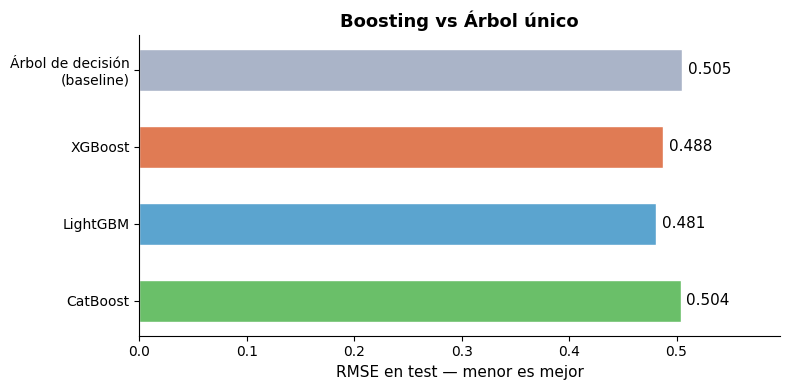

In [41]:
resultados = {
    "Árbol de decisión\n(baseline)": rmse_tree,
    "XGBoost": rmse_xgb,
    "LightGBM": rmse_lgb,
    "CatBoost": rmse_cat,
}

print("Modelo                    RMSE test")
print("-" * 36)
for modelo, rmse in resultados.items():
    nombre_limpio = modelo.replace("\n(baseline)", " (baseline)")
    print(f"{nombre_limpio:<26} {rmse:.3f}")

# Gráfico
colores = ["#aab4c8", "#e07b54", "#5ba4cf", "#6abf69"]

fig, ax = plt.subplots(figsize=(8, 4))
modelos = list(resultados.keys())
mses = list(resultados.values())

bars = ax.barh(modelos, mses, color=colores, edgecolor="white", height=0.55)
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=11)
ax.set_xlabel("RMSE en test — menor es mejor", fontsize=11)
ax.set_title("Boosting vs Árbol único", fontsize=13, fontweight="bold")
ax.set_xlim(0, max(mses) * 1.18)
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## ¿Cuándo usar cada librería?

| Librería | Úsala cuando... |
|---|---|
| **XGBoost** | Es tu primer intento — referencia sólida, muy documentada |
| **LightGBM** | Dataset grande (millones de filas) — es la más rápida |
| **CatBoost** | Muchas variables categóricas o cuando no tienes tiempo para afinar |

Las tres implementan el mismo algoritmo de fondo. La diferencia está en los detalles de implementación y optimización.